# Imports

In [8]:
import os
from collections import Counter

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, callbacks, optimizers, models

plt.rcParams['figure.figsize'] = [15, 5]

# Load Data

In [2]:
cassava_ds, cassava_info = tfds.load('cassava', with_info=True, as_supervised=True)

In [8]:
cassava_info

tfds.core.DatasetInfo(
    name='cassava',
    full_name='cassava/0.1.0',
    description="""
    Cassava consists of leaf images for the cassava plant depicting healthy and
    four (4) disease conditions; Cassava Mosaic Disease (CMD), Cassava Bacterial
    Blight (CBB), Cassava Greem Mite (CGM) and Cassava Brown Streak Disease (CBSD).
    Dataset consists of a total of 9430 labelled images.
    The 9430 labelled images are split into a training set (5656), a test set(1885)
    and a validation set (1889). The number of images per class are unbalanced with
    the two disease classes CMD and CBSD having 72% of the images.
    """,
    homepage='https://www.kaggle.com/c/cassava-disease/overview',
    data_dir='C:\\Users\\username\\tensorflow_datasets\\cassava\\0.1.0',
    file_format=tfrecord,
    download_size=1.26 GiB,
    dataset_size=1.26 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=strin

In [3]:
train, test, valid = cassava_ds['train'], cassava_ds['test'], cassava_ds['validation']

In [10]:
one_image_tf, one_label_tf = next(iter(train))
one_image = one_image_tf.numpy()
one_label = one_label_tf.numpy()

In [11]:
one_image.shape

(500, 666, 3)

In [12]:
img = cv2.cvtColor(one_image, cv2.COLOR_RGB2BGR)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

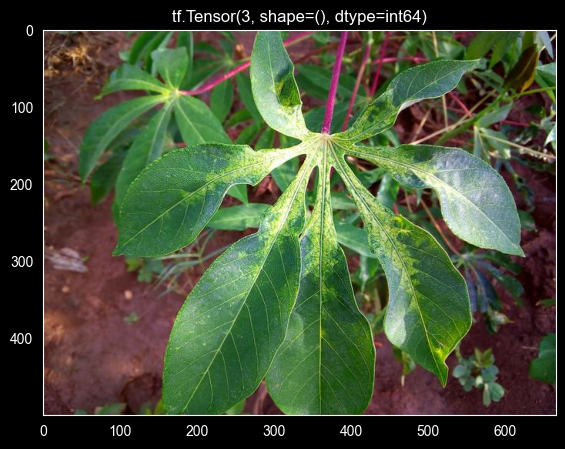

In [13]:
plt.imshow(img)
plt.title(one_label_tf)
plt.grid(False)

In [14]:
mean = np.mean(img)

red = img[..., 0]
green = img[..., 1]
blue = img[..., 2]

r_max = np.max(red)
g_max = np.max(green)
b_max = np.max(blue)

r_mean = np.mean(red)
g_mean = np.mean(green)
b_mean = np.mean(blue)

r_99 = np.quantile(red, 0.99)
g_99 = np.quantile(green, 0.99)
b_99 = np.quantile(blue, 0.99)

intensity = np.round(mean / 255 * 100, 2)

print(f'Image intensity have: {intensity}, mean: {mean}')
print(f'Red max: {r_max}, Green max: {g_max}, Blue max: {b_max}')
print(f'Red mean: {r_mean}, Green mean: {g_mean}, Blue mean: {b_mean}')
print(f'Q99 Red: {r_99}, Q99 Green: {g_99}, Q99 Blue: {b_99}')


Image intensity have: 33.31, mean: 84.93956456456456
Red max: 255, Green max: 255, Blue max: 255
Red mean: 87.30325825825825, Green mean: 99.98377177177177, Blue mean: 67.53166366366366
Q99 Red: 232.0, Q99 Green: 249.0, Q99 Blue: 206.0


(<Axes: title={'center': 'Scale-By-Max'}>,
 Text(0.5, 1.0, 'Scale-By-Max'),
 None)

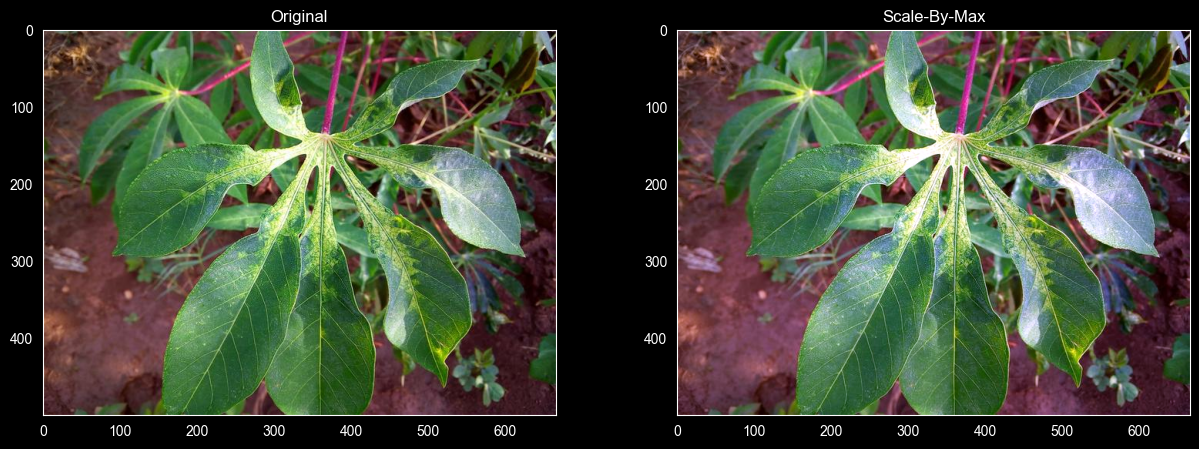

In [15]:
krq = 255.0 / r_99 if r_99 > 0 else 1.0
kgq = 255.0 / g_99 if g_99 > 0 else 1.0
kbq = 255.0 / b_99 if b_99 > 0 else 1.0

coeffs_quantile = np.array([krq, kgq, kbq], dtype=np.float64)

balanced_quantile_99 = img.astype(np.float64) * coeffs_quantile
balanced_quantile_99 = np.clip(balanced_quantile_99, 0, 255).astype(np.uint8)

plt.subplot(121), plt.title('Original'), plt.imshow(img), plt.grid(False)
plt.subplot(122), plt.title('Scale-By-Max'), plt.imshow(balanced_quantile_99), plt.grid(False)

(<matplotlib.image.AxesImage at 0x2428b5df890>, None)

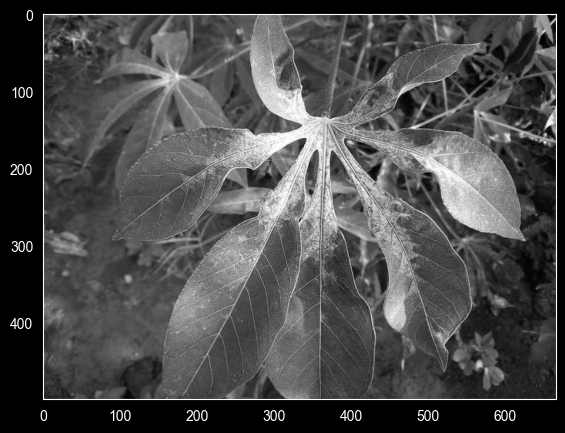

In [16]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.uint8)

plt.imshow(gray, cmap='gray'), plt.grid(False)

## Image Size pre-processing

In [4]:
# Since we have different size for each image we cannot process it as well
# We need check all images on test dataset and collect width, height and decide how to resize it

sizes = []
for image, labels in test.take(100).as_numpy_iterator():
    h,w = image.shape[:2]
    sizes.append((h,w))

collection_size = Counter(sizes)
collection_size.most_common(10)

[((666, 500), 24),
 ((500, 666), 15),
 ((500, 625), 14),
 ((500, 888), 10),
 ((500, 500), 9),
 ((888, 500), 5),
 ((500, 797), 2),
 ((500, 850), 1),
 ((500, 507), 1),
 ((500, 552), 1)]

In [11]:
# let's save original image and rescaled to understand is there any details we are lost after rescale
path = 'cassava_data'
if not os.path.exists(path):
    os.mkdir(path)

for idx, (image, labels) in enumerate(test.take(100).as_numpy_iterator()):

    h,w = image.shape[:2]

    orig_filename = f'cassava_id_{idx}_{h}_{w}_orig.jpeg'
    img = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    cv2.imwrite(os.path.join(path, orig_filename), img)

    # save re-scaled image
    scaled_file_name = f'cassava_id_{idx}_{256}_{256}_scaled.jpeg'
    img_256 = cv2.resize(img, (256, 256), interpolation=cv2.INTER_LINEAR)
    cv2.imwrite(os.path.join(path, scaled_file_name), img_256)

In [5]:
len(sizes)

100

In [6]:
df = pd.DataFrame(sizes, columns=['height', 'width'])
df.describe()

,height,width
count,100.000000,100.00000
mean,564.050000,610.22000
std,103.743407,129.53051
min,500.000000,500.00000
25%,500.000000,500.00000
50%,500.000000,616.50000
75%,666.000000,666.00000
max,888.000000,888.00000


Resize: Epoch 30/100 70ms/step - accuracy: 0.6302 - loss: 1.0381 - val_accuracy: 0.4547 - val_loss: 1.2544

Central Crop: Epoch 30/30 72ms/step - accuracy: 0.6966 - loss: 0.8350 - val_accuracy: 0.4426 - val_loss: 1.5901
Seems model is tryin' to overfit ( 0.6966 / 0.4426 ) need regulation
Focus problem - seems center cropping is particle solve problem with resizing ( but we can cut the important part of leaf )
We need implement bounding box algorithm instead and crop by box

Crop + Sharping (amount = 0.7): Epoch 28/30 68ms/step - accuracy: 0.6445 - loss: 0.9674 - val_accuracy: 0.6162 - val_loss: 1.0502
Seems model more stable ( 0.6445 / 1.0502 )

amount = 1
Epoch 30/30 134ms/step - accuracy: 0.7335 - loss: 0.7391 - val_accuracy: 0.4733 - val_loss: 1.2256
Seems it disbalance the model

In [19]:
height = 256
width = 256

def gaussian_kernel(size=5, sigma=5.0):
    x = tf.range(-size // 2 + 1, size // 2 + 1, dtype=tf.float32)
    x = tf.exp(-(x**2) / (2.0 * sigma**2))
    kernel_1d = x / tf.reduce_sum(x)

    kernel_2d = tf.tensordot(kernel_1d, kernel_1d, axes=0)
    kernel_2d = kernel_2d[:, :, tf.newaxis, tf.newaxis]
    return kernel_2d

def preprocess(image, label):

    # Stage 1: use Sharping
    image = tf.cast(image, tf.float32)
    kernel = gaussian_kernel(5, 5.0)
    kernel = tf.tile(kernel, [1, 1, 3, 1])

    blurred = tf.nn.depthwise_conv2d(
        image[tf.newaxis, ...],
        kernel,
        strides=[1, 1, 1, 1],
        padding="SAME"
    )[0]

    amount = 0.7

    sharpened = image + (image - blurred) * amount
    sharpened = tf.clip_by_value(sharpened, 0.0, 255.0)

    # Stage 2: Center Cropping
    shape = tf.shape(image)
    h = shape[0]
    w = shape[1]

    # Find smallest dimension
    min_dim = tf.minimum(h, w)

    # Center crop to square
    image = tf.image.resize_with_crop_or_pad(sharpened, min_dim, min_dim)

    # Resize to final size
    image = tf.image.resize(image, (height, width))

    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [20]:
train = train.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).cache().shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
test = test.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).cache().shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
valid = valid.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).cache().shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)

# Build CNN model

In [21]:
# shape = img.shape

model = models.Sequential([
    layers.InputLayer(shape=(height, width, 3)), # 500 x 600 x 3
    layers.Conv2D(64, 7, activation="relu",padding='same'),
    layers.MaxPooling2D(2),
    layers.Conv2D(128, 3, activation="relu", padding='same'),
    layers.Conv2D(128, 3, activation="relu", padding='same'),
    layers.MaxPooling2D(2),
    layers.Conv2D(256, 3, activation="relu", padding='same'),
    layers.Conv2D(256, 3, activation="relu", padding='same'),
    layers.MaxPooling2D(2),
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax') # total is 5 classes
])

In [22]:
model.compile(optimizer=optimizers.Adam(learning_rate=5e-3, epsilon=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'],
              )


In [ ]:
early_stopping_callback = callbacks.EarlyStopping(
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train,
    batch_size=512,
    validation_data=valid,
    epochs=100,
    callbacks=[early_stopping_callback]
) # Epoch 30/100 70ms/step - accuracy: 0.6302 - loss: 1.0381 - val_accuracy: 0.4547 - val_loss: 1.2544

Epoch 1/100
